# Business analysis

## Objectives

This notebook translates model predictions into business-oriented credit-risk
insights.

The analysis focuses on:

1. risk ranking and portfolio segmentation;
2. decile, gains and lift analysis;
3. operational threshold policies;
4. expected-cost scenarios;
5. final model recommendation;
6. model-risk, fairness and deployment limitations.

The histogram gradient-boosting model was selected during Phase 05. No model,
feature or hyperparameter selection is performed in this notebook.

Policy thresholds are designed using out-of-fold development predictions and
evaluated on the protected holdout sample.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FINAL_MODEL = "hist_gradient_boosting"
BENCHMARK_MODEL = "logistic_unweighted"

N_DECILES = 10

current_directory = Path.cwd().resolve()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

TABLE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [13]:
oof_probabilities = pd.read_csv(
    TABLE_DIR
    / "05_oof_probabilities.csv"
)

holdout_probabilities = pd.read_csv(
    TABLE_DIR
    / "05_holdout_probabilities.csv"
)

development_thresholds = pd.read_csv(
    TABLE_DIR
    / "05_development_thresholds.csv"
)

## 1. Phase 05 output audit

The Phase 05 prediction tables are audited before any business analysis.

The checks verify application uniqueness, target validity, probability bounds and
the absence of overlap between the development and protected holdout samples.

In [16]:
required_columns = {
    "SK_ID_CURR",
    "TARGET",
    FINAL_MODEL,
    BENCHMARK_MODEL,
}

for table_name, table in {
    "development_oof": oof_probabilities,
    "holdout": holdout_probabilities,
}.items():
    missing_columns = (
        required_columns
        - set(table.columns)
    )

    assert not missing_columns, (
        f"{table_name} missing columns: "
        f"{sorted(missing_columns)}"
    )

    assert table["SK_ID_CURR"].is_unique

    assert set(
        table["TARGET"].unique()
    ).issubset({0, 1})

    assert table[
        [FINAL_MODEL, BENCHMARK_MODEL]
    ].notna().all().all()

    assert table[
        [FINAL_MODEL, BENCHMARK_MODEL]
    ].ge(0).all().all()

    assert table[
        [FINAL_MODEL, BENCHMARK_MODEL]
    ].le(1).all().all()

assert set(
    oof_probabilities["SK_ID_CURR"]
).isdisjoint(
    set(holdout_probabilities["SK_ID_CURR"])
)

phase_06_input_audit = pd.DataFrame(
    {
        "sample": [
            "development_oof",
            "holdout",
        ],
        "customers": [
            len(oof_probabilities),
            len(holdout_probabilities),
        ],
        "defaults": [
            int(oof_probabilities["TARGET"].sum()),
            int(holdout_probabilities["TARGET"].sum()),
        ],
        "default_rate": [
            oof_probabilities["TARGET"].mean(),
            holdout_probabilities["TARGET"].mean(),
        ],
        "mean_predicted_pd": [
            oof_probabilities[FINAL_MODEL].mean(),
            holdout_probabilities[FINAL_MODEL].mean(),
        ],
    }
)

phase_06_input_audit.round(4)

,sample,customers,defaults,default_rate,mean_predicted_pd
0,development_oof,246008,19860,0.0807,0.0804
1,holdout,61503,4965,0.0807,0.0803


## 2. Holdout risk ranking, gains and lift

Applications are ranked from the highest to the lowest predicted probability of
default.

Risk decile 1 contains approximately the 10% highest-risk applications, while
risk decile 10 contains the 10% lowest-risk applications.

This analysis evaluates the model's ranking ability without selecting a
classification or lending-policy threshold.

In [18]:
def make_risk_ranking(
    probability_table,
    model_name,
    n_deciles=10,
):
    ranking = (
        probability_table[
            [
                "SK_ID_CURR",
                "TARGET",
                model_name,
            ]
        ]
        .rename(
            columns={
                model_name: "predicted_pd"
            }
        )
        .sort_values(
            [
                "predicted_pd",
                "SK_ID_CURR",
            ],
            ascending=[False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    n_customers = len(ranking)

    ranking["risk_decile"] = (
        np.arange(n_customers)
        * n_deciles
        // n_customers
        + 1
    )

    assert ranking[
        "predicted_pd"
    ].is_monotonic_decreasing

    return ranking

oof_risk_ranking = make_risk_ranking(
    oof_probabilities,
    FINAL_MODEL,
    N_DECILES,
)

holdout_risk_ranking = make_risk_ranking(
    holdout_probabilities,
    FINAL_MODEL,
    N_DECILES,
)

In [20]:
def make_decile_table(
    risk_ranking,
):
    n_customers = len(risk_ranking)
    total_defaults = int(
        risk_ranking["TARGET"].sum()
    )
    portfolio_default_rate = float(
        risk_ranking["TARGET"].mean()
    )

    table = (
        risk_ranking
        .groupby(
            "risk_decile",
            as_index=False,
        )
        .agg(
            customers=(
                "SK_ID_CURR",
                "size",
            ),
            defaults=(
                "TARGET",
                "sum",
            ),
            mean_predicted_pd=(
                "predicted_pd",
                "mean",
            ),
            observed_default_rate=(
                "TARGET",
                "mean",
            ),
            minimum_predicted_pd=(
                "predicted_pd",
                "min",
            ),
            maximum_predicted_pd=(
                "predicted_pd",
                "max",
            ),
        )
    )

    table["population_share"] = (
        table["customers"]
        / n_customers
    )

    table["default_share"] = (
        table["defaults"]
        / total_defaults
    )

    table["cumulative_population_share"] = (
        table["population_share"].cumsum()
    )

    table["cumulative_default_share"] = (
        table["default_share"].cumsum()
    )

    table["decile_lift"] = (
        table["observed_default_rate"]
        / portfolio_default_rate
    )

    table["cumulative_lift"] = (
        table["cumulative_default_share"]
        / table["cumulative_population_share"]
    )

    return table

oof_decile_table = make_decile_table(
    oof_risk_ranking
)

holdout_decile_table = make_decile_table(
    holdout_risk_ranking
)

holdout_decile_table[
    [
        "risk_decile",
        "customers",
        "defaults",
        "mean_predicted_pd",
        "observed_default_rate",
        "default_share",
        "cumulative_default_share",
        "decile_lift",
        "cumulative_lift",
    ]
].round(4)

,risk_decile,customers,defaults,mean_predicted_pd,observed_default_rate,default_share,cumulative_default_share,decile_lift,cumulative_lift
0,1,6151,1706,0.2728,0.2774,0.3436,0.3436,3.4357,3.4357
1,2,6150,930,0.1446,0.1512,0.1873,0.5309,1.8732,2.6545
2,3,6150,613,0.1002,0.0997,0.1235,0.6544,1.2347,2.1813
3,4,6151,515,0.0749,0.0837,0.1037,0.7581,1.0371,1.8952
4,5,6150,373,0.0581,0.0607,0.0751,0.8332,0.7513,1.6664
5,6,6150,262,0.0462,0.0426,0.0528,0.8860,0.5277,1.4767
6,7,6151,207,0.0371,0.0337,0.0417,0.9277,0.4169,1.3252
7,8,6150,180,0.0297,0.0293,0.0363,0.9639,0.3626,1.2049
8,9,6150,111,0.0233,0.0180,0.0224,0.9863,0.2236,1.0959
9,10,6150,68,0.0161,0.0111,0.0137,1.0000,0.1370,1.0000


In [22]:
def make_top_k_summary(
    risk_ranking,
    review_shares=(0.10, 0.20, 0.30),
):
    total_customers = len(risk_ranking)
    total_defaults = int(
        risk_ranking["TARGET"].sum()
    )
    portfolio_default_rate = float(
        risk_ranking["TARGET"].mean()
    )

    rows = []

    for review_share in review_shares:
        reviewed_customers = int(
            np.ceil(
                review_share
                * total_customers
            )
        )

        reviewed_portfolio = (
            risk_ranking.iloc[
                :reviewed_customers
            ]
        )

        detected_defaults = int(
            reviewed_portfolio[
                "TARGET"
            ].sum()
        )

        reviewed_default_rate = float(
            reviewed_portfolio[
                "TARGET"
            ].mean()
        )

        rows.append(
            {
                "review_share": review_share,
                "reviewed_customers": (
                    reviewed_customers
                ),
                "detected_defaults": (
                    detected_defaults
                ),
                "default_capture_rate": (
                    detected_defaults
                    / total_defaults
                ),
                "reviewed_default_rate": (
                    reviewed_default_rate
                ),
                "cumulative_lift": (
                    reviewed_default_rate
                    / portfolio_default_rate
                ),
            }
        )

    return pd.DataFrame(rows)

holdout_top_k_summary = (
    make_top_k_summary(
        holdout_risk_ranking
    )
)

holdout_top_k_summary.round(4)

,review_share,reviewed_customers,detected_defaults,default_capture_rate,reviewed_default_rate,cumulative_lift
0,0.1,6151,1706,0.3436,0.2774,3.4357
1,0.2,12301,2636,0.5309,0.2143,2.6545
2,0.3,18451,3249,0.6544,0.1761,2.1813


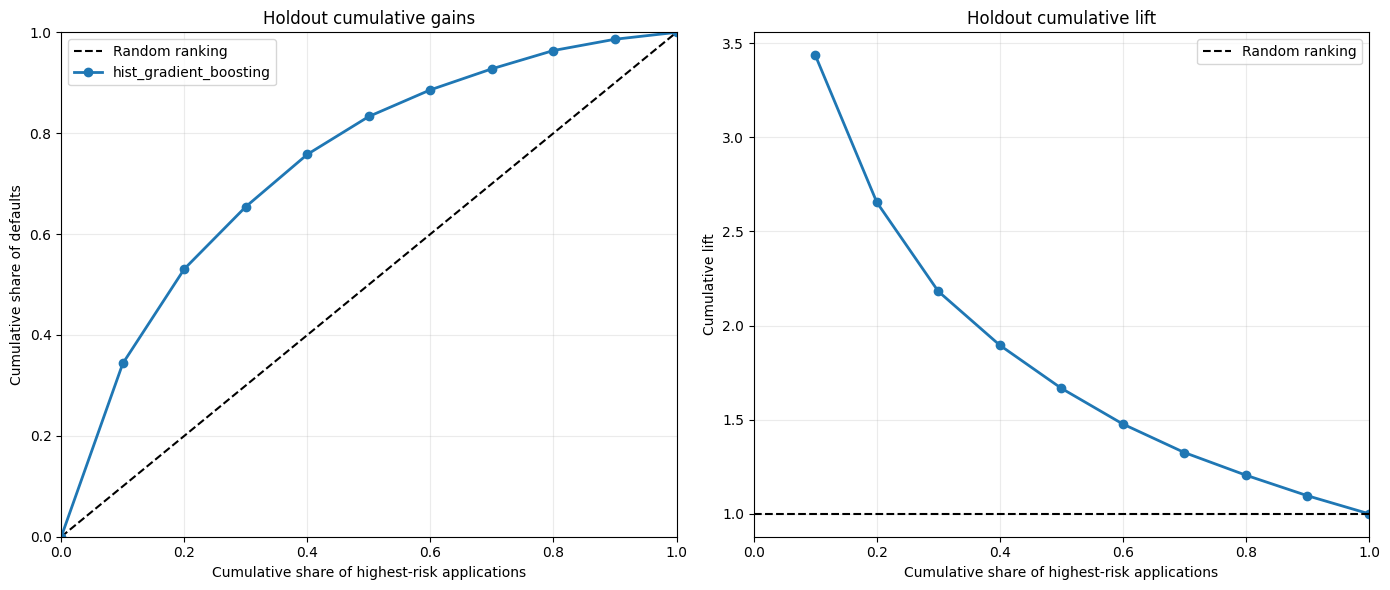

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random ranking",
)

axes[0].plot(
    np.r_[
        0,
        holdout_decile_table[
            "cumulative_population_share"
        ],
    ],
    np.r_[
        0,
        holdout_decile_table[
            "cumulative_default_share"
        ],
    ],
    marker="o",
    linewidth=2,
    label=FINAL_MODEL,
)

axes[0].set(
    xlabel=(
        "Cumulative share of "
        "highest-risk applications"
    ),
    ylabel=(
        "Cumulative share of defaults"
    ),
    title="Holdout cumulative gains",
    xlim=(0, 1),
    ylim=(0, 1),
)

axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    holdout_decile_table[
        "cumulative_population_share"
    ],
    holdout_decile_table[
        "cumulative_lift"
    ],
    marker="o",
    linewidth=2,
)

axes[1].axhline(
    1,
    linestyle="--",
    color="black",
    label="Random ranking",
)

axes[1].set(
    xlabel=(
        "Cumulative share of "
        "highest-risk applications"
    ),
    ylabel="Cumulative lift",
    title="Holdout cumulative lift",
    xlim=(0, 1),
)

axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "06_holdout_gains_lift.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Holdout ranking findings

The final model produces a clear and monotonic separation of credit risk.

The highest-risk decile has an observed default rate of 27.74%, compared with
8.07% for the full holdout portfolio and 1.11% for the lowest-risk decile. Its
decile lift is approximately 3.44.

Reviewing the 10%, 20% and 30% highest-risk applications would identify
approximately 34.36%, 53.09% and 65.44% of observed defaults, respectively.

The cumulative gains curve remains clearly above the random-ranking benchmark,
while cumulative lift gradually converges to 1 as the reviewed share approaches
the full portfolio.

These results demonstrate strong risk-ranking performance. They do not by
themselves determine an approval, rejection or manual-review policy. Operational
thresholds must be designed on development OOF predictions before being evaluated
on the holdout sample.

## 3. Development-based risk segmentation

Three monitoring segments are defined using score cutoffs estimated exclusively
from development OOF predictions:

- high risk: the highest-risk 20% of the development portfolio;
- medium risk: the following 30%;
- low risk: the remaining 50%.

These bands provide a simple portfolio-monitoring framework. They are not
automatic lending decisions and do not incorporate profitability, exposure,
loss-given-default or regulatory constraints.

The numerical OOF cutoffs are frozen before being applied to the protected
holdout sample.

In [25]:
RISK_BAND_ORDER = [
    "high",
    "medium",
    "low",
]

medium_risk_cutoff = float(
    oof_probabilities[
        FINAL_MODEL
    ].quantile(0.50)
)

high_risk_cutoff = float(
    oof_probabilities[
        FINAL_MODEL
    ].quantile(0.80)
)

assert (
    high_risk_cutoff
    > medium_risk_cutoff
)

risk_band_cutoffs = pd.DataFrame(
    {
        "boundary": [
            "medium_to_high",
            "low_to_medium",
        ],
        "oof_quantile": [
            0.80,
            0.50,
        ],
        "predicted_pd_cutoff": [
            high_risk_cutoff,
            medium_risk_cutoff,
        ],
    }
)

risk_band_cutoffs

,boundary,oof_quantile,predicted_pd_cutoff
0,medium_to_high,0.8,0.117597
1,low_to_medium,0.5,0.051820


In [27]:
def add_risk_band(
    probability_table,
    model_name,
    medium_cutoff,
    high_cutoff,
):
    segmented = probability_table[
        [
            "SK_ID_CURR",
            "TARGET",
            model_name,
        ]
    ].copy()

    segmented = segmented.rename(
        columns={
            model_name: "predicted_pd"
        }
    )

    segmented["risk_band"] = np.select(
        [
            segmented[
                "predicted_pd"
            ].ge(high_cutoff),
            segmented[
                "predicted_pd"
            ].ge(medium_cutoff),
        ],
        [
            "high",
            "medium",
        ],
        default="low",
    )

    segmented["risk_band"] = pd.Categorical(
        segmented["risk_band"],
        categories=RISK_BAND_ORDER,
        ordered=True,
    )

    return segmented

oof_risk_segments = add_risk_band(
    oof_probabilities,
    FINAL_MODEL,
    medium_risk_cutoff,
    high_risk_cutoff,
)

holdout_risk_segments = add_risk_band(
    holdout_probabilities,
    FINAL_MODEL,
    medium_risk_cutoff,
    high_risk_cutoff,
)

In [29]:
def summarize_risk_bands(
    segmented_table,
    sample_name,
):
    n_customers = len(segmented_table)
    total_defaults = int(
        segmented_table[
            "TARGET"
        ].sum()
    )
    portfolio_default_rate = float(
        segmented_table[
            "TARGET"
        ].mean()
    )

    summary = (
        segmented_table
        .groupby(
            "risk_band",
            observed=True,
            as_index=False,
        )
        .agg(
            customers=(
                "SK_ID_CURR",
                "size",
            ),
            defaults=(
                "TARGET",
                "sum",
            ),
            mean_predicted_pd=(
                "predicted_pd",
                "mean",
            ),
            observed_default_rate=(
                "TARGET",
                "mean",
            ),
            minimum_predicted_pd=(
                "predicted_pd",
                "min",
            ),
            maximum_predicted_pd=(
                "predicted_pd",
                "max",
            ),
        )
    )

    summary.insert(
        0,
        "sample",
        sample_name,
    )

    summary["population_share"] = (
        summary["customers"]
        / n_customers
    )

    summary["default_share"] = (
        summary["defaults"]
        / total_defaults
    )

    summary["risk_lift"] = (
        summary["observed_default_rate"]
        / portfolio_default_rate
    )

    return summary

risk_band_summary = pd.concat(
    [
        summarize_risk_bands(
            oof_risk_segments,
            "development_oof",
        ),
        summarize_risk_bands(
            holdout_risk_segments,
            "holdout",
        ),
    ],
    ignore_index=True,
)

risk_band_summary[
    [
        "sample",
        "risk_band",
        "customers",
        "population_share",
        "defaults",
        "default_share",
        "mean_predicted_pd",
        "observed_default_rate",
        "risk_lift",
    ]
].round(4)

,sample,risk_band,customers,population_share,defaults,default_share,mean_predicted_pd,observed_default_rate,risk_lift
0,development_oof,high,49202,0.2000,10379,0.5226,0.2088,0.2109,2.6130
1,development_oof,medium,73802,0.3000,6059,0.3051,0.0778,0.0821,1.0170
2,development_oof,low,123004,0.5000,3422,0.1723,0.0306,0.0278,0.3446
3,holdout,high,12278,0.1996,2631,0.5299,0.2089,0.2143,2.6544
4,holdout,medium,18357,0.2985,1497,0.3015,0.0779,0.0815,1.0102
5,holdout,low,30868,0.5019,837,0.1686,0.0305,0.0271,0.3359


In [33]:
customer_totals_by_sample = (
    risk_band_summary
    .groupby("sample")["customers"]
    .sum()
    .to_dict()
)

expected_customer_totals = {
    "development_oof": len(
        oof_probabilities
    ),
    "holdout": len(
        holdout_probabilities
    ),
}

default_totals_by_sample = (
    risk_band_summary
    .groupby("sample")["defaults"]
    .sum()
    .to_dict()
)

expected_default_totals = {
    "development_oof": int(
        oof_probabilities[
            "TARGET"
        ].sum()
    ),
    "holdout": int(
        holdout_probabilities[
            "TARGET"
        ].sum()
    ),
}

assert (
    customer_totals_by_sample
    == expected_customer_totals
)

assert (
    default_totals_by_sample
    == expected_default_totals
)

### Risk-segmentation findings

The OOF-derived cutoffs are 0.1176 between the medium- and high-risk
segments and 0.0518 between the low- and medium-risk segments.

When these frozen cutoffs are applied to the holdout sample, the high-risk
segment represents 19.96% of applications and contains 52.99% of observed
defaults. Its observed default rate is 21.43%, corresponding to a risk lift
of approximately 2.65 relative to the full holdout portfolio.

The medium-risk segment represents 29.85% of applications and has an observed
default rate of 8.15%, close to the portfolio average. The low-risk segment
contains 50.19% of applications but only 16.86% of observed defaults, with a
default rate of 2.71%.

Segment sizes, mean predicted probabilities and observed default rates remain
close between development OOF and holdout samples. This indicates stability
within the current random split, but it does not establish temporal or
out-of-population stability.

These segments are intended for monitoring and policy analysis. They should not
be interpreted as automatic approval or rejection decisions.

## 4. Development-designed operational review policies

Three capacity-based manual-review scenarios are designed using development
OOF predictions:

- review approximately the highest-risk 10% of applications;
- review approximately the highest-risk 20%;
- review approximately the highest-risk 30%.

The OOF maximum-F1 threshold from Phase 05 is included as a diagnostic
comparator. It is not interpreted as an economically optimal lending policy.

All numerical cutoffs are determined before holdout evaluation. Because the
same score cutoffs are applied unchanged, the actual reviewed share on holdout
may differ slightly from its development target.

In [34]:
REVIEW_CAPACITY_SHARES = (
    0.10,
    0.20,
    0.30,
)

policy_rows = []

for review_share in (
    REVIEW_CAPACITY_SHARES
):
    score_cutoff = float(
        oof_probabilities[
            FINAL_MODEL
        ].quantile(
            1.0 - review_share
        )
    )

    policy_rows.append(
        {
            "policy": (
                f"review_top_"
                f"{int(100 * review_share)}pct"
            ),
            "policy_type": (
                "capacity_based"
            ),
            "target_review_share": (
                review_share
            ),
            "score_cutoff": (
                score_cutoff
            ),
            "cutoff_source": (
                "development_oof_quantile"
            ),
        }
    )

final_model_f1_threshold = (
    development_thresholds.loc[
        development_thresholds[
            "model"
        ].eq(FINAL_MODEL)
    ]
)

assert len(
    final_model_f1_threshold
) == 1

policy_rows.append(
    {
        "policy": "oof_max_f1",
        "policy_type": (
            "diagnostic_comparator"
        ),
        "target_review_share": np.nan,
        "score_cutoff": float(
            final_model_f1_threshold[
                "threshold"
            ].iloc[0]
        ),
        "cutoff_source": (
            "development_oof_max_f1"
        ),
    }
)

operational_policy_cutoffs = (
    pd.DataFrame(policy_rows)
)

assert (
    operational_policy_cutoffs[
        "score_cutoff"
    ].between(0, 1).all()
)

assert operational_policy_cutoffs[
    "policy"
].is_unique

operational_policy_cutoffs.round(6)

,policy,policy_type,target_review_share,score_cutoff,cutoff_source
0,review_top_10pct,capacity_based,0.1,0.180732,development_oof_quantile
1,review_top_20pct,capacity_based,0.2,0.117597,development_oof_quantile
2,review_top_30pct,capacity_based,0.3,0.085594,development_oof_quantile
3,oof_max_f1,diagnostic_comparator,NaN,0.143454,development_oof_max_f1


In [35]:
def safe_divide(
    numerator,
    denominator,
):
    if denominator == 0:
        return np.nan

    return numerator / denominator


def summarize_operational_policies(
    probability_table,
    model_name,
    policy_cutoffs,
    sample_name,
):
    scores = probability_table[
        model_name
    ].to_numpy()

    target = probability_table[
        "TARGET"
    ].astype(int).to_numpy()

    total_customers = len(target)
    total_defaults = int(
        target.sum()
    )
    total_non_defaults = (
        total_customers
        - total_defaults
    )

    portfolio_default_rate = (
        total_defaults
        / total_customers
    )

    rows = []

    for policy in (
        policy_cutoffs.itertuples(
            index=False
        )
    ):
        flagged = (
            scores
            >= policy.score_cutoff
        )

        flagged_customers = int(
            flagged.sum()
        )

        flagged_defaults = int(
            (
                flagged
                & (target == 1)
            ).sum()
        )

        flagged_non_defaults = int(
            (
                flagged
                & (target == 0)
            ).sum()
        )

        missed_defaults = int(
            (
                ~flagged
                & (target == 1)
            ).sum()
        )

        unflagged_non_defaults = int(
            (
                ~flagged
                & (target == 0)
            ).sum()
        )

        flagged_share = safe_divide(
            flagged_customers,
            total_customers,
        )

        flagged_default_rate = (
            safe_divide(
                flagged_defaults,
                flagged_customers,
            )
        )

        default_capture_rate = (
            safe_divide(
                flagged_defaults,
                total_defaults,
            )
        )

        precision = (
            flagged_default_rate
        )
        recall = (
            default_capture_rate
        )

        f1 = safe_divide(
            2 * precision * recall,
            precision + recall,
        )

        rows.append(
            {
                "sample": sample_name,
                "policy": policy.policy,
                "policy_type": (
                    policy.policy_type
                ),
                "target_review_share": (
                    policy.target_review_share
                ),
                "score_cutoff": (
                    policy.score_cutoff
                ),
                "customers": (
                    total_customers
                ),
                "flagged_customers": (
                    flagged_customers
                ),
                "flagged_share": (
                    flagged_share
                ),
                "flagged_defaults": (
                    flagged_defaults
                ),
                "flagged_non_defaults": (
                    flagged_non_defaults
                ),
                "missed_defaults": (
                    missed_defaults
                ),
                "unflagged_non_defaults": (
                    unflagged_non_defaults
                ),
                "flagged_default_rate": (
                    flagged_default_rate
                ),
                "default_capture_rate": (
                    default_capture_rate
                ),
                "review_lift": (
                    safe_divide(
                        flagged_default_rate,
                        portfolio_default_rate,
                    )
                ),
                "false_positive_rate": (
                    safe_divide(
                        flagged_non_defaults,
                        total_non_defaults,
                    )
                ),
                "f1": f1,
            }
        )

    return pd.DataFrame(rows)

In [36]:
operational_policy_summary = (
    pd.concat(
        [
            summarize_operational_policies(
                probability_table=(
                    oof_probabilities
                ),
                model_name=FINAL_MODEL,
                policy_cutoffs=(
                    operational_policy_cutoffs
                ),
                sample_name=(
                    "development_oof"
                ),
            ),
            summarize_operational_policies(
                probability_table=(
                    holdout_probabilities
                ),
                model_name=FINAL_MODEL,
                policy_cutoffs=(
                    operational_policy_cutoffs
                ),
                sample_name="holdout",
            ),
        ],
        ignore_index=True,
    )
)

operational_policy_summary[
    [
        "sample",
        "policy",
        "score_cutoff",
        "flagged_customers",
        "flagged_share",
        "flagged_defaults",
        "flagged_non_defaults",
        "missed_defaults",
        "flagged_default_rate",
        "default_capture_rate",
        "review_lift",
        "f1",
    ]
].round(4)

,sample,policy,score_cutoff,flagged_customers,flagged_share,flagged_defaults,flagged_non_defaults,missed_defaults,flagged_default_rate,default_capture_rate,review_lift,f1
0,development_oof,review_top_10pct,0.1807,24601,0.1000,6716,17885,13144,0.2730,0.3382,3.3816,0.3021
1,development_oof,review_top_20pct,0.1176,49202,0.2000,10379,38823,9481,0.2109,0.5226,2.6130,0.3006
2,development_oof,review_top_30pct,0.0856,73803,0.3000,12975,60828,6885,0.1758,0.6533,2.1777,0.2771
3,development_oof,oof_max_f1,0.1435,36569,0.1486,8704,27865,11156,0.2380,0.4383,2.9483,0.3085
4,holdout,review_top_10pct,0.1807,6123,0.0996,1700,4423,3265,0.2776,0.3424,3.4392,0.3066
5,holdout,review_top_20pct,0.1176,12278,0.1996,2631,9647,2334,0.2143,0.5299,2.6544,0.3052
6,holdout,review_top_30pct,0.0856,18477,0.3004,3251,15226,1714,0.1759,0.6548,2.1795,0.2774
7,holdout,oof_max_f1,0.1435,9115,0.1482,2214,6901,2751,0.2429,0.4459,3.0088,0.3145


### Operational-policy findings

The OOF-derived score cutoffs transfer consistently to the protected holdout
sample. The 10%, 20% and 30% capacity-based policies flag 9.96%, 19.96% and
30.04% of holdout applications, respectively.

The highest-risk 10% of applications have an observed default rate of 27.76%
and contain 34.24% of holdout defaults, corresponding to a review lift of
approximately 3.44.

Expanding review capacity to approximately 20% captures 52.99% of defaults,
with a reviewed default rate of 21.43%. This policy uses the same cutoff as the
previously defined high-risk segment.

Reviewing approximately 30% captures 65.48% of defaults, but lowers the
reviewed default rate to 17.59% and substantially increases operational
workload.

The OOF maximum-F1 comparator flags 14.82% of holdout applications and achieves
the highest holdout F1 score, 0.3145. However, this does not make it an
economically optimal policy because F1 assigns no explicit value to review
costs, preventable credit losses or operational capacity.

Policy selection therefore requires explicit assumptions about manual-review
cost, default loss and the effectiveness of the intervention triggered by
review.

## 5. Expected-cost scenario analysis

The dataset does not contain exposure at default, loss given default, loan
revenue, manual-review cost or the observed effectiveness of a review
intervention.

Consequently, this section does not estimate actual monetary profitability.
Instead, it performs an illustrative sensitivity analysis using normalized cost
units.

For each policy, expected cost is defined as:

\[
C =
c_{\mathrm{review}} N_{\mathrm{flagged}}
+
c_{\mathrm{default}}
\left[
N_{\mathrm{missed\ defaults}}
+
(1-e)N_{\mathrm{flagged\ defaults}}
\right],
\]

where \(e\) is the assumed proportion of defaults among reviewed applications
that the intervention can prevent.

Candidate policies are compared and selected exclusively on development OOF
predictions. The selected policy is then evaluated unchanged on holdout data.
The maximum-F1 threshold remains a diagnostic comparator and is not eligible
for business-policy selection.

In [37]:
COST_SCENARIOS = pd.DataFrame(
    {
        "scenario": [
            "low_effectiveness",
            "moderate_value",
            "base_case",
            "high_default_loss",
        ],
        "review_cost": [
            1.0,
            1.0,
            1.0,
            1.0,
        ],
        "default_loss": [
            10.0,
            10.0,
            15.0,
            25.0,
        ],
        "review_effectiveness": [
            0.20,
            0.50,
            0.50,
            0.50,
        ],
    }
)

assert COST_SCENARIOS[
    "scenario"
].is_unique

assert COST_SCENARIOS[
    "review_cost"
].gt(0).all()

assert COST_SCENARIOS[
    "default_loss"
].gt(0).all()

assert COST_SCENARIOS[
    "review_effectiveness"
].between(0, 1).all()

COST_SCENARIOS

,scenario,review_cost,default_loss,review_effectiveness
0,low_effectiveness,1.0,10.0,0.2
1,moderate_value,1.0,10.0,0.5
2,base_case,1.0,15.0,0.5
3,high_default_loss,1.0,25.0,0.5


In [39]:
def make_expected_cost_table(
    policy_summary,
    cost_scenarios,
):
    rows = []

    for (
        sample_name,
        sample_policies,
    ) in policy_summary.groupby(
        "sample",
        sort=False,
    ):
        assert (
            sample_policies[
                "customers"
            ].nunique()
            == 1
        )

        total_customers = int(
            sample_policies[
                "customers"
            ].iloc[0]
        )

        total_defaults_by_policy = (
            sample_policies[
                "flagged_defaults"
            ]
            + sample_policies[
                "missed_defaults"
            ]
        )

        assert (
            total_defaults_by_policy.nunique()
            == 1
        )

        total_defaults = int(
            total_defaults_by_policy.iloc[0]
        )

        candidates = [
            {
                "policy": "no_review",
                "policy_type": "no_review",
                "flagged_customers": 0,
                "flagged_defaults": 0,
                "missed_defaults": (
                    total_defaults
                ),
            }
        ]

        candidates.extend(
            sample_policies[
                [
                    "policy",
                    "policy_type",
                    "flagged_customers",
                    "flagged_defaults",
                    "missed_defaults",
                ]
            ].to_dict("records")
        )

        for scenario in (
            cost_scenarios.itertuples(
                index=False
            )
        ):
            no_review_cost = (
                scenario.default_loss
                * total_defaults
            )

            for candidate in candidates:
                expected_residual_defaults = (
                    candidate[
                        "missed_defaults"
                    ]
                    + (
                        1.0
                        - scenario.review_effectiveness
                    )
                    * candidate[
                        "flagged_defaults"
                    ]
                )

                expected_cost = (
                    scenario.review_cost
                    * candidate[
                        "flagged_customers"
                    ]
                    + scenario.default_loss
                    * expected_residual_defaults
                )

                rows.append(
                    {
                        "sample": sample_name,
                        "scenario": (
                            scenario.scenario
                        ),
                        "policy": (
                            candidate["policy"]
                        ),
                        "policy_type": (
                            candidate[
                                "policy_type"
                            ]
                        ),
                        "eligible_for_selection": (
                            candidate[
                                "policy_type"
                            ]
                            in {
                                "no_review",
                                "capacity_based",
                            }
                        ),
                        "review_cost": (
                            scenario.review_cost
                        ),
                        "default_loss": (
                            scenario.default_loss
                        ),
                        "review_effectiveness": (
                            scenario
                            .review_effectiveness
                        ),
                        "expected_residual_defaults": (
                            expected_residual_defaults
                        ),
                        "expected_cost": (
                            expected_cost
                        ),
                        "expected_cost_per_application": (
                            expected_cost
                            / total_customers
                        ),
                        "savings_vs_no_review": (
                            no_review_cost
                            - expected_cost
                        ),
                        "savings_rate_vs_no_review": (
                            (
                                no_review_cost
                                - expected_cost
                            )
                            / no_review_cost
                        ),
                    }
                )

    return pd.DataFrame(rows)

expected_cost_results = (
    make_expected_cost_table(
        policy_summary=(
            operational_policy_summary
        ),
        cost_scenarios=COST_SCENARIOS,
    )
)

oof_cost_comparison = (
    expected_cost_results.loc[
        expected_cost_results[
            "sample"
        ].eq("development_oof")
    ]
    .pivot(
        index="scenario",
        columns="policy",
        values=(
            "expected_cost_per_application"
        ),
    )
)

oof_cost_comparison.round(4)

policy,no_review,oof_max_f1,review_top_10pct,review_top_20pct,review_top_30pct
scenario,,,,,
base_case,1.2109,1.0942,1.1062,1.0945,1.1154
high_default_loss,2.0182,1.7246,1.7770,1.6909,1.6590
low_effectiveness,0.8073,0.8852,0.8527,0.9229,1.0018
moderate_value,0.8073,0.7790,0.7708,0.7963,0.8436


In [40]:
eligible_oof_costs = (
    expected_cost_results.loc[
        expected_cost_results[
            "sample"
        ].eq("development_oof")
        & expected_cost_results[
            "eligible_for_selection"
        ]
    ]
)

selected_oof_indices = (
    eligible_oof_costs
    .groupby("scenario")[
        "expected_cost"
    ]
    .idxmin()
)

oof_policy_choices = (
    eligible_oof_costs.loc[
        selected_oof_indices,
        [
            "scenario",
            "policy",
            "expected_cost_per_application",
            "savings_rate_vs_no_review",
        ],
    ]
    .rename(
        columns={
            "policy": "selected_policy",
            "expected_cost_per_application": (
                "oof_expected_cost_per_application"
            ),
            "savings_rate_vs_no_review": (
                "oof_savings_rate_vs_no_review"
            ),
        }
    )
    .reset_index(drop=True)
)

oof_policy_choices.round(4)

,scenario,selected_policy,oof_expected_cost_per_application,oof_savings_rate_vs_no_review
0,base_case,review_top_20pct,1.0945,0.0961
1,high_default_loss,review_top_30pct,1.6590,0.1780
2,low_effectiveness,no_review,0.8073,0.0000
3,moderate_value,review_top_10pct,0.7708,0.0452


In [41]:
selected_policy_evaluation = (
    expected_cost_results
    .merge(
        oof_policy_choices[
            [
                "scenario",
                "selected_policy",
            ]
        ],
        on="scenario",
        how="inner",
    )
    .loc[
        lambda table: table[
            "policy"
        ].eq(
            table["selected_policy"]
        ),
        [
            "scenario",
            "sample",
            "selected_policy",
            "expected_cost_per_application",
            "savings_vs_no_review",
            "savings_rate_vs_no_review",
        ],
    ]
    .sort_values(
        [
            "scenario",
            "sample",
        ]
    )
    .reset_index(drop=True)
)

selected_policy_evaluation.round(4)

,scenario,sample,selected_policy,expected_cost_per_application,savings_vs_no_review,savings_rate_vs_no_review
0,base_case,development_oof,review_top_20pct,1.0945,28640.5,0.0961
1,base_case,holdout,review_top_20pct,1.0897,7454.5,0.1001
2,high_default_loss,development_oof,review_top_30pct,1.6590,88384.5,0.1780
3,high_default_loss,holdout,review_top_30pct,1.6579,22160.5,0.1785
4,low_effectiveness,development_oof,no_review,0.8073,0.0,0.0000
5,low_effectiveness,holdout,no_review,0.8073,0.0,0.0000
6,moderate_value,development_oof,review_top_10pct,0.7708,8979.0,0.0452
7,moderate_value,holdout,review_top_10pct,0.7686,2377.0,0.0479


### Expected-cost findings

The economically preferred review capacity depends materially on the assumed
default loss and intervention effectiveness.

Under the low-effectiveness scenario, manual review is not cost-saving. The
development-based selection is therefore no review.

When review effectiveness is assumed to be 50% and default loss equals 10
normalized review-cost units, reviewing the highest-risk 10% is selected. The
illustrative savings rate is 4.52% on development OOF predictions and 4.79% on
holdout.

Under the base-case assumptions, reviewing the highest-risk 20% is selected.
This policy produces illustrative savings of 9.61% on development OOF and
10.01% on holdout.

When the relative cost of default increases to 25 units, reviewing the
highest-risk 30% becomes preferable, with savings rates of 17.80% on
development OOF and 17.85% on holdout.

The close OOF and holdout results indicate stability within the current random
split. They do not establish actual profitability because the cost and
effectiveness parameters are hypothetical.

The maximum-F1 threshold remains a diagnostic comparator and is excluded from
business-policy selection. Its classification objective does not represent an
operational capacity or economic requirement.

## 6. Break-even intervention effectiveness

A review policy is less costly than no review when:

\[
e >
\frac{
c_{\mathrm{review}}N_{\mathrm{flagged}}
}{
c_{\mathrm{default}}N_{\mathrm{flagged\ defaults}}
}
=
\frac{
c_{\mathrm{review}}
}{
c_{\mathrm{default}}
\times
\mathrm{flagged\ default\ rate}
}.
\]

This defines the minimum intervention effectiveness required for a policy to
offset its review workload.

Break-even thresholds are calculated exclusively from development OOF results.
A policy exceeding break-even is cheaper than no review under the specified
scenario, but it is not necessarily the least-cost policy among all available
review capacities.

In [42]:
oof_capacity_metrics = (
    operational_policy_summary.loc[
        operational_policy_summary[
            "sample"
        ].eq("development_oof")
        & operational_policy_summary[
            "policy_type"
        ].eq("capacity_based"),
        [
            "policy",
            "flagged_customers",
            "flagged_defaults",
            "flagged_default_rate",
        ],
    ]
    .copy()
)

assert oof_capacity_metrics[
    "flagged_defaults"
].gt(0).all()

break_even_rows = []

for scenario in COST_SCENARIOS.itertuples(
    index=False
):
    for policy in (
        oof_capacity_metrics.itertuples(
            index=False
        )
    ):
        break_even_effectiveness = (
            scenario.review_cost
            / (
                scenario.default_loss
                * policy.flagged_default_rate
            )
        )

        effectiveness_margin = (
            scenario.review_effectiveness
            - break_even_effectiveness
        )

        break_even_rows.append(
            {
                "scenario": scenario.scenario,
                "policy": policy.policy,
                "review_cost": (
                    scenario.review_cost
                ),
                "default_loss": (
                    scenario.default_loss
                ),
                "flagged_default_rate": (
                    policy.flagged_default_rate
                ),
                "assumed_effectiveness": (
                    scenario
                    .review_effectiveness
                ),
                "break_even_effectiveness": (
                    break_even_effectiveness
                ),
                "effectiveness_margin": (
                    effectiveness_margin
                ),
                "cost_saving_at_assumption": (
                    effectiveness_margin > 0
                ),
            }
        )

break_even_analysis = pd.DataFrame(
    break_even_rows
)

assert break_even_analysis[
    "break_even_effectiveness"
].gt(0).all()

break_even_analysis[
    [
        "scenario",
        "policy",
        "assumed_effectiveness",
        "break_even_effectiveness",
        "effectiveness_margin",
        "cost_saving_at_assumption",
    ]
].round(4)

,scenario,policy,assumed_effectiveness,break_even_effectiveness,effectiveness_margin,cost_saving_at_assumption
0,low_effectiveness,review_top_10pct,0.2,0.3663,-0.1663,False
1,low_effectiveness,review_top_20pct,0.2,0.4741,-0.2741,False
2,low_effectiveness,review_top_30pct,0.2,0.5688,-0.3688,False
3,moderate_value,review_top_10pct,0.5,0.3663,0.1337,True
4,moderate_value,review_top_20pct,0.5,0.4741,0.0259,True
5,moderate_value,review_top_30pct,0.5,0.5688,-0.0688,False
6,base_case,review_top_10pct,0.5,0.2442,0.2558,True
7,base_case,review_top_20pct,0.5,0.3160,0.1840,True
8,base_case,review_top_30pct,0.5,0.3792,0.1208,True
9,high_default_loss,review_top_10pct,0.5,0.1465,0.3535,True


In [43]:
base_case_policy = (
    oof_policy_choices.loc[
        oof_policy_choices[
            "scenario"
        ].eq("base_case"),
        "selected_policy",
    ]
    .item()
)

base_case_cutoff = (
    operational_policy_cutoffs.loc[
        operational_policy_cutoffs[
            "policy"
        ].eq(base_case_policy),
        "score_cutoff",
    ]
    .item()
)

base_case_holdout_policy = (
    operational_policy_summary.loc[
        operational_policy_summary[
            "sample"
        ].eq("holdout")
        & operational_policy_summary[
            "policy"
        ].eq(base_case_policy)
    ]
)

assert len(base_case_holdout_policy) == 1

base_case_holdout_policy = (
    base_case_holdout_policy.iloc[0]
)

base_case_holdout_cost = (
    selected_policy_evaluation.loc[
        selected_policy_evaluation[
            "scenario"
        ].eq("base_case")
        & selected_policy_evaluation[
            "sample"
        ].eq("holdout")
    ]
)

assert len(base_case_holdout_cost) == 1

base_case_holdout_cost = (
    base_case_holdout_cost.iloc[0]
)

final_business_recommendation = (
    pd.DataFrame(
        [
            {
                "model": FINAL_MODEL,
                "scenario": "base_case",
                "policy": base_case_policy,
                "score_cutoff": (
                    base_case_cutoff
                ),
                "holdout_review_share": (
                    base_case_holdout_policy[
                        "flagged_share"
                    ]
                ),
                "holdout_default_capture_rate": (
                    base_case_holdout_policy[
                        "default_capture_rate"
                    ]
                ),
                "holdout_reviewed_default_rate": (
                    base_case_holdout_policy[
                        "flagged_default_rate"
                    ]
                ),
                "holdout_review_lift": (
                    base_case_holdout_policy[
                        "review_lift"
                    ]
                ),
                "holdout_savings_rate_vs_no_review": (
                    base_case_holdout_cost[
                        "savings_rate_vs_no_review"
                    ]
                ),
            }
        ]
    )
)

final_business_recommendation.round(4)

,model,scenario,policy,score_cutoff,holdout_review_share,holdout_default_capture_rate,holdout_reviewed_default_rate,holdout_review_lift,holdout_savings_rate_vs_no_review
0,hist_gradient_boosting,base_case,review_top_20pct,0.1176,0.1996,0.5299,0.2143,2.6544,0.1001


## 7. Final business recommendation

The histogram gradient-boosting model remains the analytical champion selected
during Phase 05. It provides strong risk ranking, useful portfolio separation
and stable results between development OOF and the protected holdout sample.

Under the explicitly defined base-case assumptions, the preferred
capacity-based policy is to manually review applications with predicted
probability of default greater than or equal to 0.1176.

This corresponds to approximately the highest-risk 20% of the development
portfolio and is identical to the previously defined high-risk segment.

When applied unchanged to holdout data, this policy:

- reviews 19.96% of applications;
- captures 52.99% of observed defaults;
- produces a reviewed default rate of 21.43%;
- achieves a review lift of approximately 2.65;
- produces an illustrative 10.01% cost reduction relative to no review.

This is a conditional scenario recommendation, not evidence of actual monetary
profitability. The 0.1176 cutoff should be interpreted as a candidate
manual-review threshold rather than an automatic approval or rejection rule.

Given the absence of temporal validation, real exposure and loss information,
intervention outcomes and fairness assessment, the appropriate next step would
be a controlled shadow-mode or manual-review pilot rather than immediate
automated deployment.

## 8. Model-risk, fairness and deployment limitations

### Economic limitations

The analysis uses normalized assumptions because exposure at default, loss given
default, interest revenue, recovery, review cost and intervention effectiveness
are unavailable. Real policy selection requires institution-specific estimates
of these quantities.

The analysis also assumes that review can prevent a fixed proportion of defaults.
This is not a causal estimate and must be validated through operational data or
a controlled pilot.

### Validation limitations

The current holdout is generated from a random split. Similar OOF and holdout
results therefore demonstrate internal stability, but not temporal,
out-of-population or macroeconomic stability.

Before deployment, the model should be evaluated on an out-of-time sample and,
where possible, on a population representing the intended production portfolio.

### Fairness and compliance

No formal fairness assessment has been performed. Applicant characteristics and
proxy variables may produce different error rates, calibration quality or
approval outcomes across protected or vulnerable groups.

A production review should include legally appropriate subgroup analyses,
calibration checks, false-positive and false-negative comparisons, adverse
impact assessment and documented feature governance.

### Monitoring and governance

A production monitoring framework should track:

- input schema and missing-value changes;
- population and score drift;
- calibration and observed default rates by risk band;
- review volume and default capture;
- operational overrides and intervention outcomes;
- subgroup performance and fairness indicators;
- model degradation and retraining triggers.

Decisions should remain auditable, with documented threshold approval, reason
codes, human oversight and a challenger-model process.

In [44]:
TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

phase_06_exports = {
    "06_input_audit.csv": (
        phase_06_input_audit
    ),
    "06_oof_decile_table.csv": (
        oof_decile_table
    ),
    "06_holdout_decile_table.csv": (
        holdout_decile_table
    ),
    "06_holdout_top_k_summary.csv": (
        holdout_top_k_summary
    ),
    "06_risk_band_cutoffs.csv": (
        risk_band_cutoffs
    ),
    "06_risk_band_summary.csv": (
        risk_band_summary
    ),
    "06_operational_policy_cutoffs.csv": (
        operational_policy_cutoffs
    ),
    "06_operational_policy_summary.csv": (
        operational_policy_summary
    ),
    "06_cost_scenarios.csv": (
        COST_SCENARIOS
    ),
    "06_expected_cost_results.csv": (
        expected_cost_results
    ),
    "06_oof_policy_choices.csv": (
        oof_policy_choices
    ),
    "06_selected_policy_evaluation.csv": (
        selected_policy_evaluation
    ),
    "06_break_even_analysis.csv": (
        break_even_analysis
    ),
    "06_final_business_recommendation.csv": (
        final_business_recommendation
    ),
}

for filename, table in (
    phase_06_exports.items()
):
    table.to_csv(
        TABLE_DIR / filename,
        index=False,
    )

exported_paths = [
    TABLE_DIR / filename
    for filename in phase_06_exports
]

assert all(
    path.exists()
    for path in exported_paths
)

pd.DataFrame(
    {
        "exported_file": [
            path.name
            for path in exported_paths
        ]
    }
)

,exported_file
0,06_input_audit.csv
1,06_oof_decile_table.csv
2,06_holdout_decile_table.csv
3,06_holdout_top_k_summary.csv
4,06_risk_band_cutoffs.csv
5,06_risk_band_summary.csv
6,06_operational_policy_cutoffs.csv
7,06_operational_policy_summary.csv
8,06_cost_scenarios.csv
9,06_expected_cost_results.csv
